# Telco Customer Churn — Classification Project
**Dataset:** [Telco Customer Churn (IBM sample dataset)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
**Target variable:** `Churn` (Yes / No) — whether the customer left the company within the last month.

This notebook covers : Preprocessing, Decision Tree, Rule-Based Classification,
kNN, ensemble learning (Random Forest, AdaBoost), and a final model comparison.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 30)

---
### 3. Data Understanding & Preprocessing

Load the data and get an overview

In [2]:
!pip install kagglehub


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import KaggleHub
import kagglehub

In [4]:
import pandas as pd
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 4. Initial Dataset Inspection

- Dataset Shape (`df.shape`): Displays the number of rows and columns in the dataset.
- Column Names (`df.columns`): Lists all available features and attributes.
- Data Types (`df.dtypes`): Shows the data type of each column, helping identify numerical and categorical variables.
- Missing Values (`df.isnull().sum()`): Checks for null or missing values in each feature to assess data quality.
- Summary Statistics (`df.describe()`): Provides descriptive statistics such as count, mean, standard deviation, minimum, maximum, and quartiles for numerical features.
- Target Variable Distribution (`df['churn'].value_counts()`): Displays the number of customers who churned and those who were retained.
- Churn Rate Calculation (`df['churn'].mean()`): Calculates the percentage of customers who have churned, providing an initial indication of class balance within the dataset.

In [6]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

print("\nTarget variable distribution:")
print(df['Churn'].value_counts())


Shape:
(7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                

#### Summary — Initial Data Exploration

Shape & Structure
- **7,043 rows × 21 columns** — one row per customer.

Data Types
- **4 numeric columns:** `SeniorCitizen` (int64, binary/nominal in practice), `tenure` (int64), `MonthlyCharges` (float64), `TotalCharges` (str, float64 in practice).
- **16 string/object columns** — mostly Yes/No or multi-category text fields requiring encoding before modeling.
- `customerID` is an identifier, not a feature.

Summary Statistics (numeric columns only)
| Column | Observation |
|---|---|
| `SeniorCitizen` | Mean ≈ 0.162 → **~16.2% of customers are senior citizens** |
| `tenure` | Range 0–72 months, mean ≈ 32.4, median 29 — wide spread of new vs. long-term customers |
| `MonthlyCharges` | Range $18.25–$118.75, mean ≈ $64.76 — no implausible values |
| `TotalCharges` | Column is incorrectly mapped as String, hence describe() excludes this column |

Target Distribution (`Churn`)
- **No: 5,174 (73.5%)**
- **Yes: 1,869 (26.5%)**
- A **moderately imbalanced binary target (~1 : 2.8)**.

Key Takeaways
- Data is clean overall — only one small, fully explainable missingness pattern; no wild outliers in the summary stats.
- The **class imbalance (~73.5% / 26.5%)** is the most important finding here:
  - Justifies **stratified train/test splitting** to preserve this ratio in both sets.
  - Means **accuracy alone is a weak metric** — a model predicting "No" for every customer would already score ~73.5% without learning anything.
  - Motivates tracking **Precision, Recall, and Specificity** explicitly in later evaluation.

In [7]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
# isolate just the rows where it's now NaN
missing_rows = df[df['TotalCharges'].isnull()]
print(missing_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


Diagnosis: every single row with a missing `TotalCharges` has `tenure = 0` — these are
brand-new customers who haven't been billed yet, so `TotalCharges` is genuinely undefined
(not "missing at random"). That's only **11 / 7043 rows (0.16%)**.

Handling decision: we **drop these 11 rows** rather than impute, because the proportion is negligible (0.16%), so dropping costs almost no information.

In [8]:
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print("Shape after dropping missing TotalCharges rows:", df.shape)

Shape after dropping missing TotalCharges rows: (7032, 21)


**Duplicates.** `customerID` is a unique key, so we check duplication on the *attribute
columns only* (excluding the ID). 


In [9]:
exact_dupes = df.duplicated().sum()
attr_dupes = df.drop(columns=['customerID']).duplicated().sum()
print(f"Fully identical rows (incl. customerID): {exact_dupes}")
print(f"Rows with identical attributes, different customerID: {attr_dupes}")

Fully identical rows (incl. customerID): 0
Rows with identical attributes, different customerID: 22


These records were retained because they represent different customer IDs. Identical demographic and subscription attributes do not establish that the records are duplicate observations.

In [10]:
#checking unique values for categorical columns
for column in df.select_dtypes(include="object"):
    print(column, df[column].unique())

customerID <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3,

C:\Users\tannistha.ganguly\AppData\Local\Temp\ipykernel_43428\2614027520.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object"):


### 5. Attribute classification (Nominal / Ordinal / Numeric)

| Column | Type | Column | Type |
|---|---|---|---|
| customerID | Identifier (excluded from modeling) | OnlineBackup | Nominal |
| gender | Nominal (binary) | DeviceProtection | Nominal |
| SeniorCitizen | Nominal (binary)* | TechSupport | Nominal |
| Partner | Nominal (binary) | StreamingTV | Nominal |
| Dependents | Nominal (binary) | StreamingMovies | Nominal |
| tenure | Numeric — Discrete | Contract | **Ordinal*** |
| PhoneService | Nominal (binary) | PaperlessBilling | Nominal (binary) |
| MultipleLines | Nominal | PaymentMethod | Nominal |
| InternetService | Nominal | MonthlyCharges | Numeric — Continuous |
| OnlineSecurity | Nominal | TotalCharges | Numeric — Continuous |
| | | Churn (target) | Nominal (binary) |

**Three non-obvious cases, explained:**

1. **`SeniorCitizen`** is stored as an `int64` (0/1), which might be treated as numeric.
   But 0 and 1 here just encode "No"/"Yes" — there's no meaningful magnitude, order, or
   arithmetic ("1.5 senior citizens" is meaningless, and the distance between 0 and 1 doesn't
   represent a quantity). 

2. **`Contract`** (`Month-to-month`, `One year`, `Two year`) is **ordinal**, not nominal —
   unlike `PaymentMethod` or `InternetService`, these three values have a real, meaningful
   order (increasing commitment length). We encode it as `0/1/2` rather than one-hot, so the
   model can (if useful) exploit the "more commitment → different churn risk" ordering
   instead of treating "Two year" and "Month-to-month" as arbitrarily unrelated sub-categories.

3. **`tenure`** is **numeric-discrete** — it's recorded in whole months
   (integer count of billing cycles), so it can only take integer values 0–72. 

4. **`TotalCharges`** *looks* like it should be a simple derived feature
   (`tenure × MonthlyCharges`). We will gather more information about this feature before we take any decision.


### 6. Univariate Distribution Analysis — `tenure`, `MonthlyCharges`, `TotalCharges`

This code plots histograms (with KDE overlay) for the three continuous numeric features,
then quantifies each distribution's asymmetry with skewness.



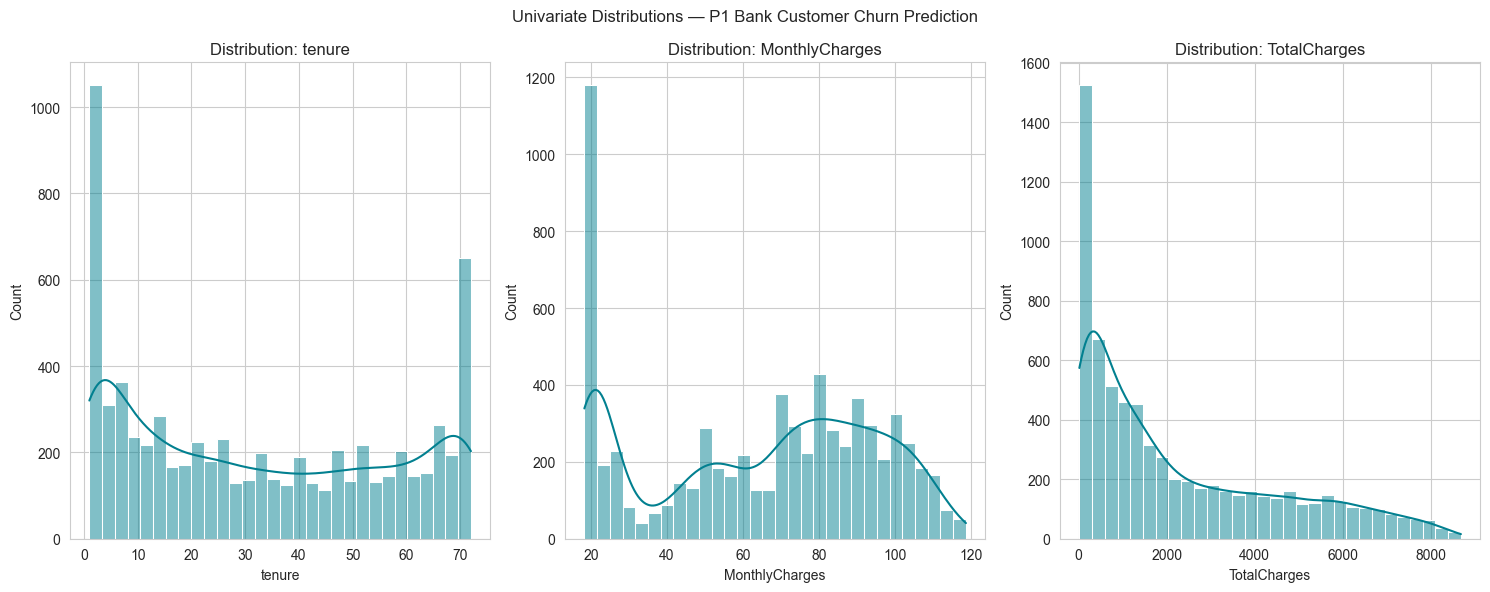

tenure            0.237731
MonthlyCharges   -0.222103
TotalCharges      0.961642
dtype: float64


In [ ]:
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 6)) 

for ax, col in zip(axes.flat, cols):  
    sns.histplot(df[col], kde=True, ax=ax,
                 color='#028090', edgecolor='white', bins=30)
    ax.set_title(f'Distribution: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Univariate Distributions')
plt.tight_layout()
plt.show()

print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].skew())

Skewness Results

| Column | Skewness | Interpretation |
|---|---|---|
| `tenure` | **0.24** | Roughly symmetric, very slight right skew — customers are fairly spread across short and long tenures |
| `MonthlyCharges` | **-0.22** | Roughly symmetric, very slight left skew — no strong tail in either direction |
| `TotalCharges` | **0.96** | Moderately right-skewed — a longer tail toward high values |

Distribution Shapes (from the histograms)

- **`tenure`** (range 0–72, mean ≈ 32.4, median 29): distribution is almost **bimodal* — a large
  cluster of very new customers near `tenure = 0`, plus a build-up of
  long-tenured customers near 72. This reflects the mix of frequent early churners and loyal
  long-term customers.
- **`MonthlyCharges`** (range \$18–\$119, mean ≈ \$64.76): exhibits a bimodal (or multimodal) distribution with a prominent cluster of customers on low-cost plans and a larger cluster on higher-cost plans. Its skewness of −0.22 indicates only a very slight left skew, so skewness is not the most informative description of its shape.
- **`TotalCharges`** (range \$18.80–\$8,684.80, mean ≈ \$2,283, median ≈ \$1,397): the
  most skewed of the three — mean > median confirms the right skew already flagged by
  the skewness value. 






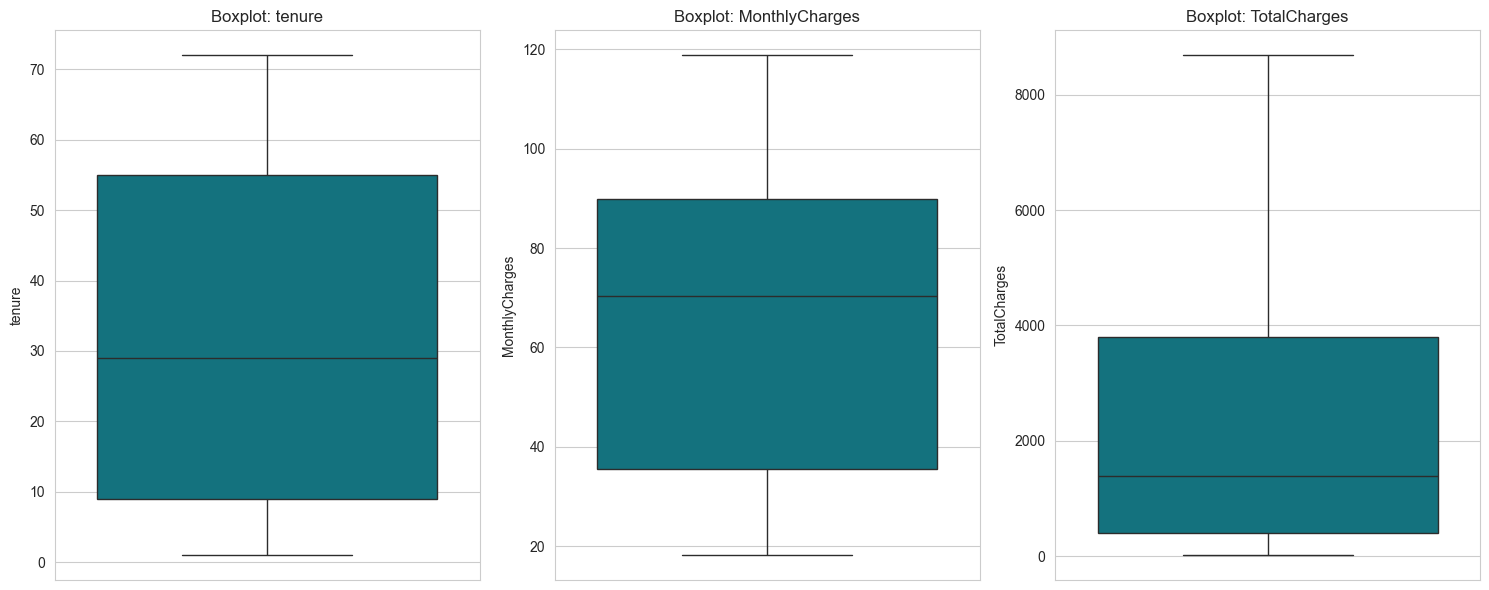

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [12]:
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax, color='#028090', flierprops=dict(
        marker='o', color='red', markersize=4,
        alpha=0.5))
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel(col)

# Hide the last empty subplot
#axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Count outliers numerically
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5 * IQR) |
         (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'{col}: {n} outliers')

Observations

| Column | Median | IQR (Box) | Whisker Range | Outliers (points beyond whiskers) |
|---|---|---|---|---|
| `tenure` | ~29 | ~9 – 55 | 0 – 72 | **None** |
| `MonthlyCharges` | ~70 | ~35 – 90 | ~18 – 119 | **None** |
| `TotalCharges` | ~1,400 | ~400 – 3,800 | ~0 – 8,700 | **None** |

Key Takeaways

- **No individual outlier points appear beyond either whisker in any of the three plots** —
  this confirms the earlier IQR calculation (all bounds computed as `Q1 - 1.5×IQR` to
  `Q3 + 1.5×IQR` contained 100% of the data, 0 flagged rows per column).
- The **whiskers reach all the way to the min/max of each column** (e.g. `tenure`'s upper
  whisker sits at 72, its true maximum). This is expected: `tenure`
  is capped by the data collection window (max 72 months), and charges are bounded by
  realistic pricing plans.
- **`TotalCharges` has the most visibly right-skewed box** — its median (~1,400) sits much
  closer to the bottom of the box than the top, and the box itself is noticeably taller on
  the upper side (~400 to ~3,800) than a symmetric distribution would produce. This matches
  the skewness value (~0.96) calculated separately.

C:\Users\tannistha.ganguly\AppData\Local\Temp\ipykernel_43428\2904233170.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, order=df[col].value_counts().index,
C:\Users\tannistha.ganguly\AppData\Local\Temp\ipykernel_43428\2904233170.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, order=df[col].value_counts().index,
C:\Users\tannistha.ganguly\AppData\Local\Temp\ipykernel_43428\2904233170.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, order=df[col].value_count

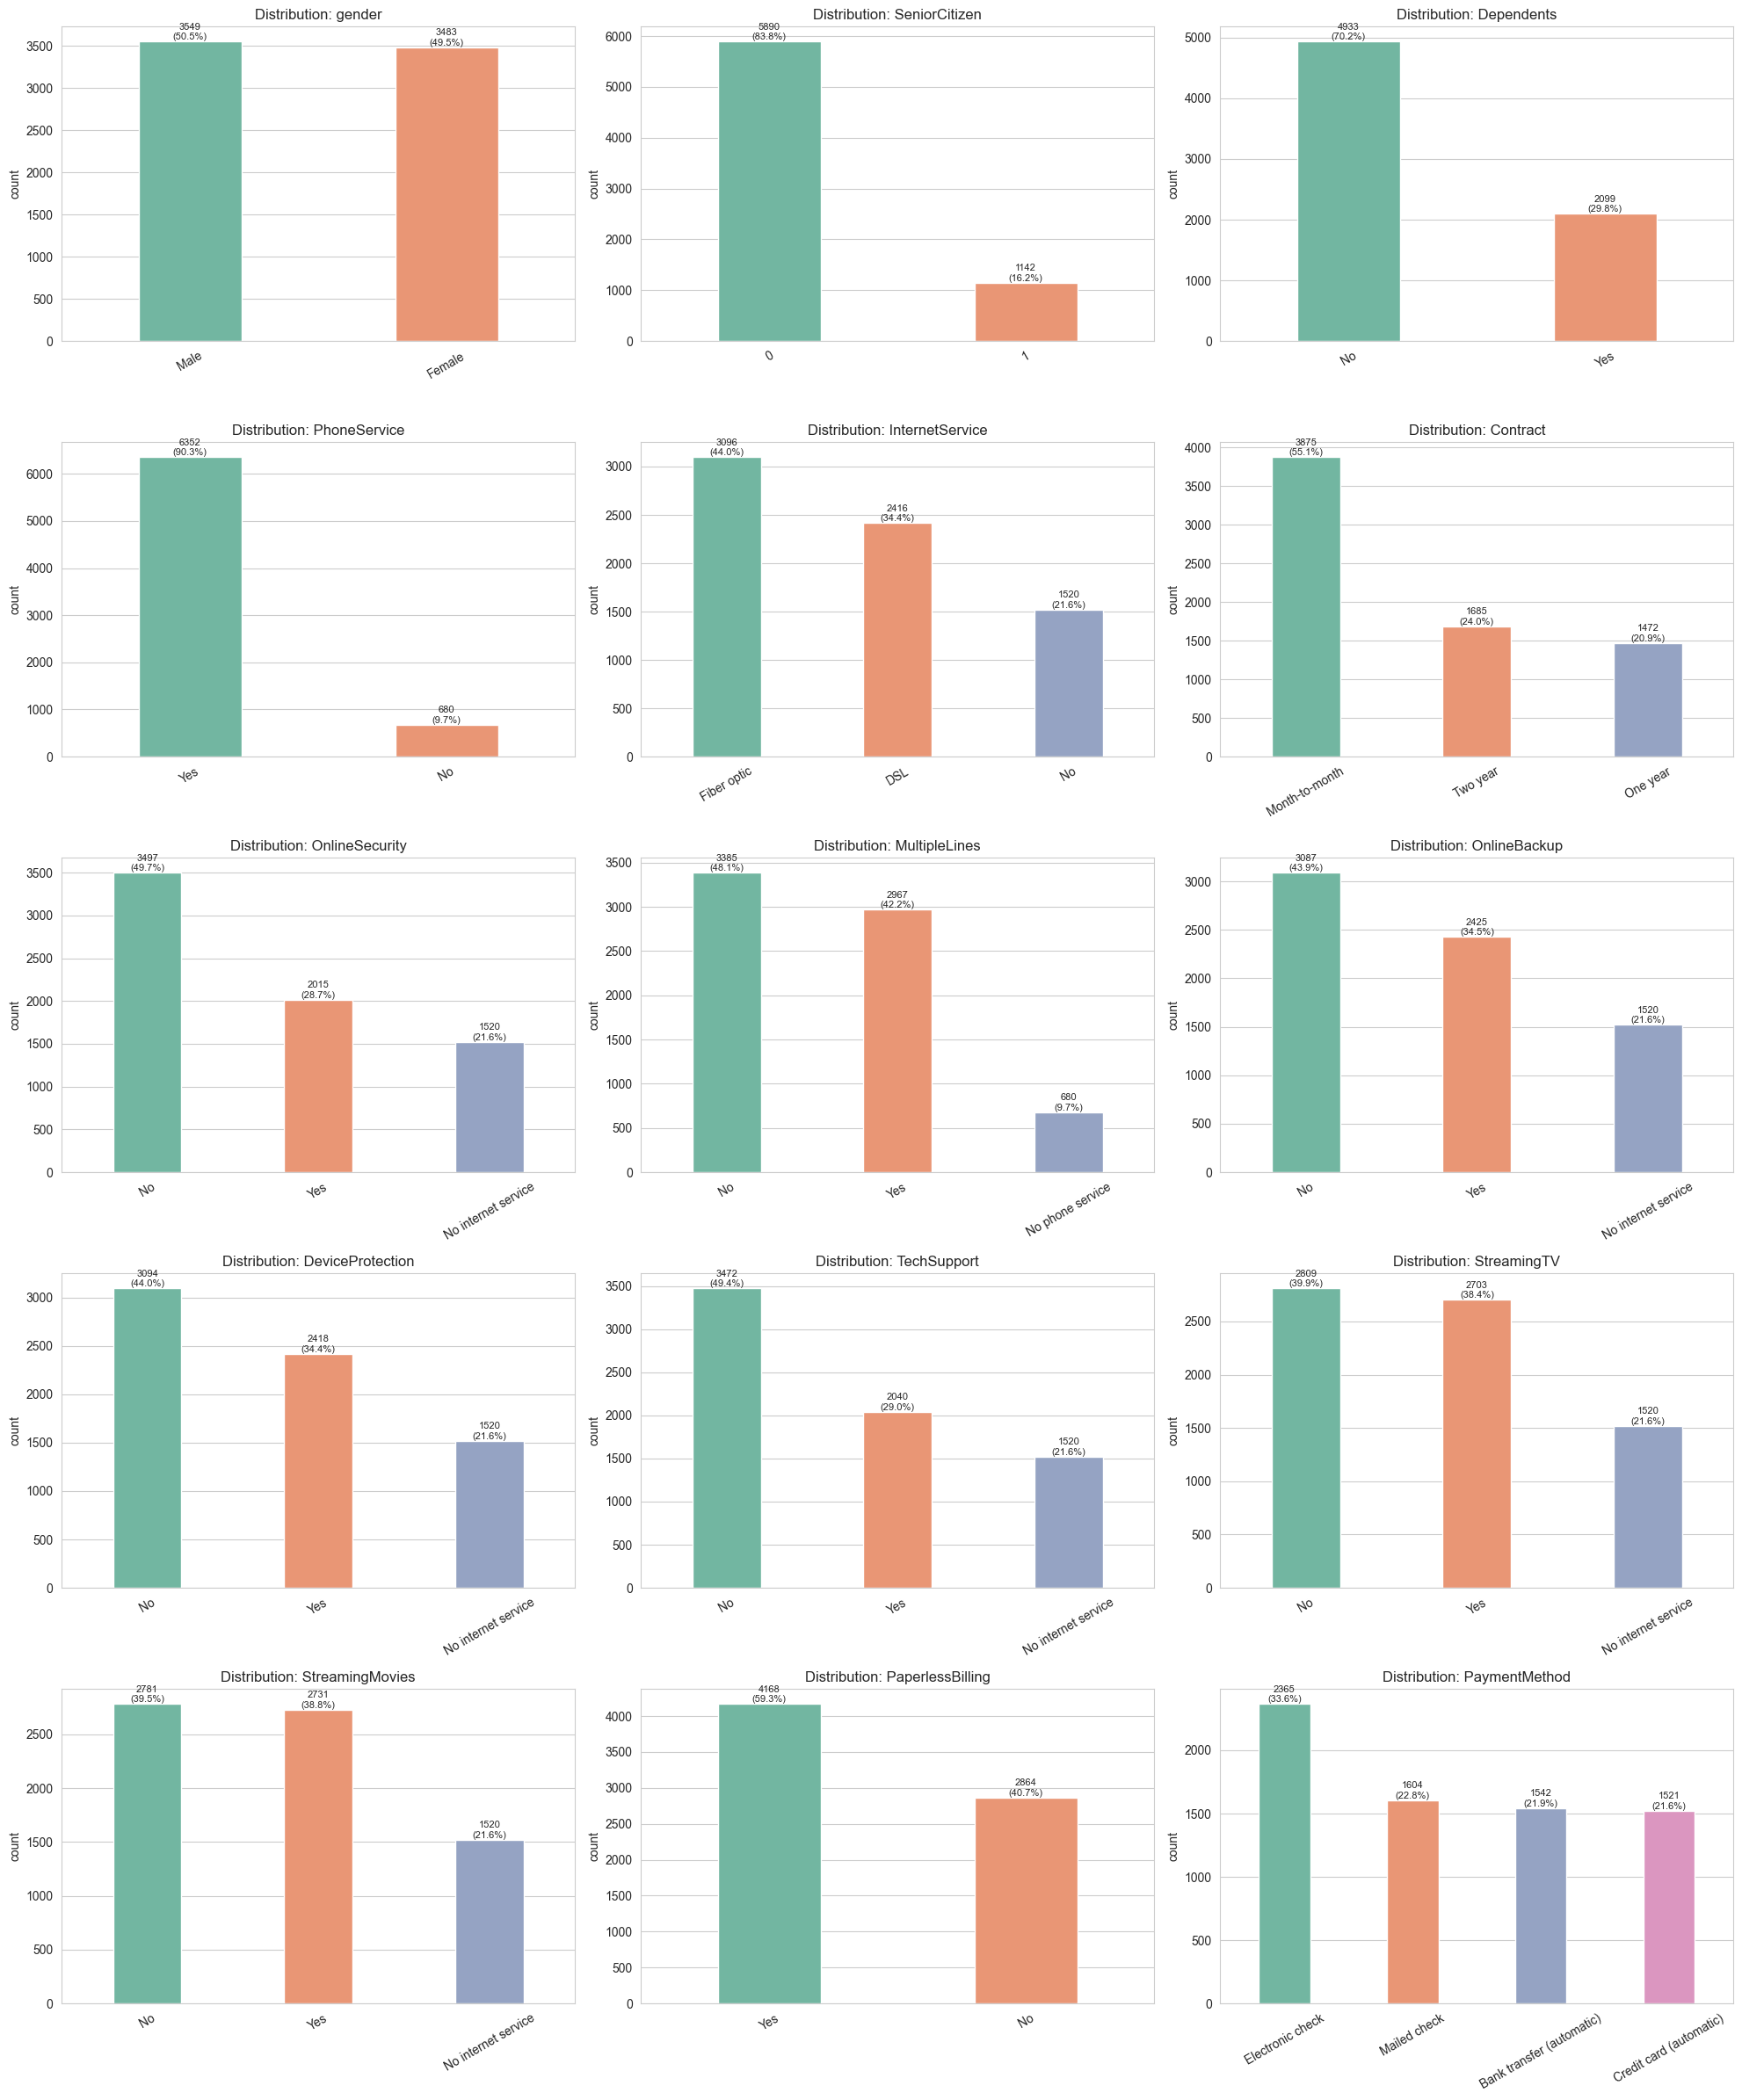

In [13]:
cat_cols = ['gender', 'SeniorCitizen', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'OnlineSecurity', 'MultipleLines', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
fig, axes = plt.subplots(5, 3, figsize=(20, 24))

for ax, col in zip(axes.flat, cat_cols):
    sns.countplot(x=col, data=df, ax=ax, order=df[col].value_counts().index,
                  palette='Set2', edgecolor='white', width=0.4)
    ax.set(title=f'Distribution: {col}', xlabel='')
    total = len(df)
    for p in ax.patches:
        cnt = int(p.get_height())
        ax.annotate(f'{cnt}\n({100*cnt/total:.1f}%)',
                    (p.get_x() + p.get_width()/2, cnt),
                    ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Demographics — Balanced, Except One

| Feature | Split | Conclusion |
|---|---|---|
| `gender` | Male 50.5% / Female 49.5% | Evenly distributed |
| `SeniorCitizen` | No 83.8% / Yes 16.2% | Strongly imbalanced — only ~1 in 6 customers is a senior citizen |
| `Dependents` | No 70.2% / Yes 29.8% | Skewed toward customers with no dependents |

**Takeaway:** demographic features are mostly imbalanced toward "typical" customers (younger,
no dependents) — worth watching whether the minority groups (seniors, those with dependents)
show different churn behavior, since a 16% minority class can still carry real signal.

Service Subscriptions — Most Customers Are Under-Subscribed

- `PhoneService`: 90.3% Yes — phone service is nearly universal.
- `InternetService`: Fiber optic (44.0%) > DSL (34.4%) > No (21.6%) — **no single
  majority class**.
- `Add-on services` (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
  `StreamingTV`, `StreamingMovies`): all follow the **same repeating pattern** —
  roughly **~44% No / ~30–39% Yes / ~21.6% "No internet service."**
  - The constant **21.6% "No internet service"** category across all six columns is not a
    coincidence — it's the **same 1,520 customers** (those with `InternetService = "No"`)
    propagating an identical "not applicable" label into every dependent add-on column.
    This is a **structural redundancy**: these six columns are partially determined by
    `InternetService`, which matters for encoding decisions (one-hot encoding preserves
    this fine, but it's worth knowing the "No internet service" category isn't independent
    information).
  - Among customers who *do* have internet, opt-in rates for **security/support services**
    (OnlineSecurity, TechSupport ≈ 28–29% Yes) are lower than opt-in rates for
    **entertainment services** (StreamingTV, StreamingMovies ≈ 38–39% Yes) — customers favor
    convenience/entertainment add-ons over protective ones.
- **`MultipleLines`**: No 48.1% / Yes 42.2% / No phone service 9.7% — fairly balanced between
  single- and multi-line customers.

Overall Conclusions

1. **No missing or malformed categories** — every bar sums cleanly to 7,043 (or the internet-
   service-conditioned subset), confirming the categorical encoding step downstream can
   proceed without needing to handle stray/unexpected category values.
2. **Three features stand out as likely strong churn predictors purely from their skew**:
   `Contract`, `InternetService`  and `PaymentMethod` (electronic check as the largest
   non-automatic method) — all three align with well-known churn risk factors before even
   touching the target variable.
3. **The repeated "No internet service" bucket (21.6%) across six columns** is a structural
   artifact of the schema, not six independent signals — useful to know for feature
   engineering (e.g. these columns are collectively redundant with `InternetService == "No"`).

In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### 7. Bivariate Distribution Analysis 

<Figure size 1200x800 with 0 Axes>

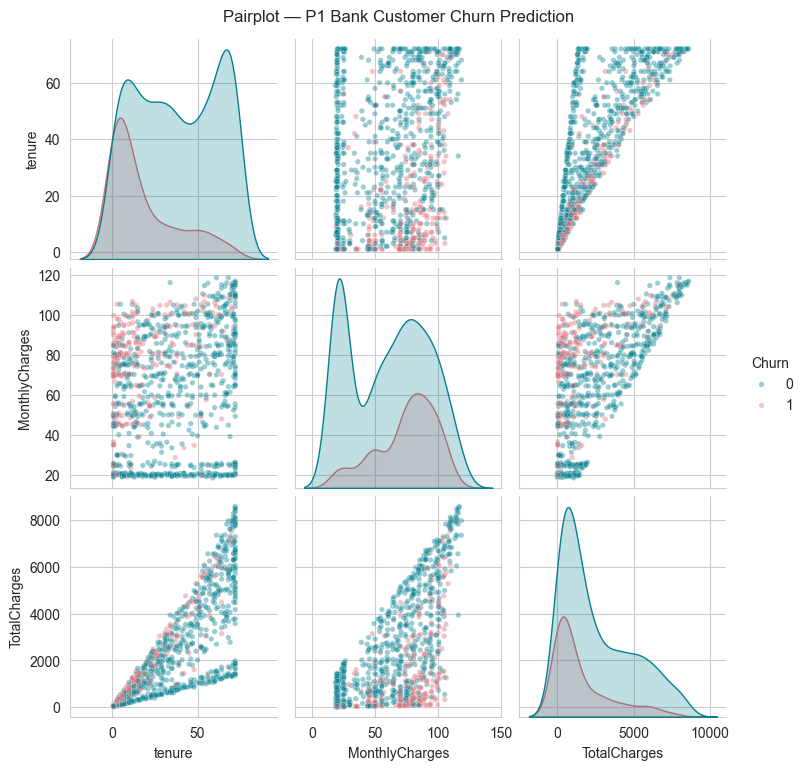

In [ ]:
plt.figure(figsize=(12, 8))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
sample = df.sample(1000)
sns.pairplot(
 sample[numeric_cols + ['Churn']],
 hue='Churn',
 palette={0:'#028090',1:'#E06C75'},
 plot_kws={'alpha':0.4, 's':15},
 diag_kind='kde')
plt.suptitle('Pairplot', y=1.02)
plt.show()

#### Pairplot Analysis — Numeric Features by Churn Status

A pairplot of `tenure`, `MonthlyCharges`, and `TotalCharges`, colored by `Churn`
(0 = No, teal / 1 = Yes, pink), showing pairwise scatter relationships (off-diagonal)
and per-class KDE distributions (diagonal).

Diagonal — Per-Feature Distributions Split by Churn

- **`tenure`**: The two classes look **strikingly different**. Non-churners (teal) show a
  **bimodal distribution** — a large group of very new customers plus a second peak near
  the max tenure (~70 months), consistent with a stable base of both new sign-ups and loyal
  long-timers. Churners (pink) are **heavily concentrated at low tenure** and drop off
  sharply as tenure increases — **the longer a customer stays, the less likely they are to
  churn**. This is the clearest single-feature signal in the whole plot.
- **`MonthlyCharges`**: Non-churners peak around **~20** (cheap, likely single-service
  plans) with a secondary bump near ~80–90. Churners are **concentrated at higher charges**
  (~70–100), suggesting customers on pricier plans churn more.
- **`TotalCharges`**: Both classes are right-skewed, but churners are **much more concentrated
  near low `TotalCharges`** values. This is expected — it's largely a downstream consequence
  of low tenure (few billing cycles = low cumulative spend), not necessarily an independent
  signal.

Off-Diagonal — Pairwise Relationships

- **`tenure` vs `TotalCharges`**: Strong **positive, near-linear relationship**, exactly as
  expected since `TotalCharges ≈ tenure × MonthlyCharges`. Churners (pink) cluster tightly
  along the **low-tenure / low-TotalCharges corner** of this triangle, visually confirming
  that churn is concentrated among customers who both joined recently and have paid little
  so far.
- **`tenure` vs `MonthlyCharges`**: No strong linear pattern, but churners are visibly denser
  in the **low-tenure, high-MonthlyCharges** region — new customers paying a lot are the
  highest-risk combination.
- **`MonthlyCharges` vs `TotalCharges`**: Points fan out from the origin because
  `TotalCharges` depends on both `MonthlyCharges` and `tenure` — this scatter is really a
  2D projection of a 3-variable relationship, so it's less directly interpretable on its own
  than the other two panels.

Key Conclusions

1. **`tenure` is the strongest of the three numeric churn predictors** — its distribution
   split by class is the most visually separated, and it drives the clear clustering seen in
   both scatter panels involving it.
2. **High `MonthlyCharges` + low `tenure` is the highest-risk combination** — this matches
   the "new customer on an expensive plan" churn profile.
3. **`TotalCharges` adds little independent signal beyond `tenure` and `MonthlyCharges`** —
   its churn pattern is largely explained by the other two, since it's arithmetically
   derived from them. 
4. **No class perfectly separates from the other** in any 2D projection — churners and
   non-churners overlap substantially everywhere, confirming that numeric features alone
   won't produce a simple linear decision boundary. This supports using a model that can
   capture non-linear interactions (Decision Tree, Random Forest) over a purely linear
   approach.

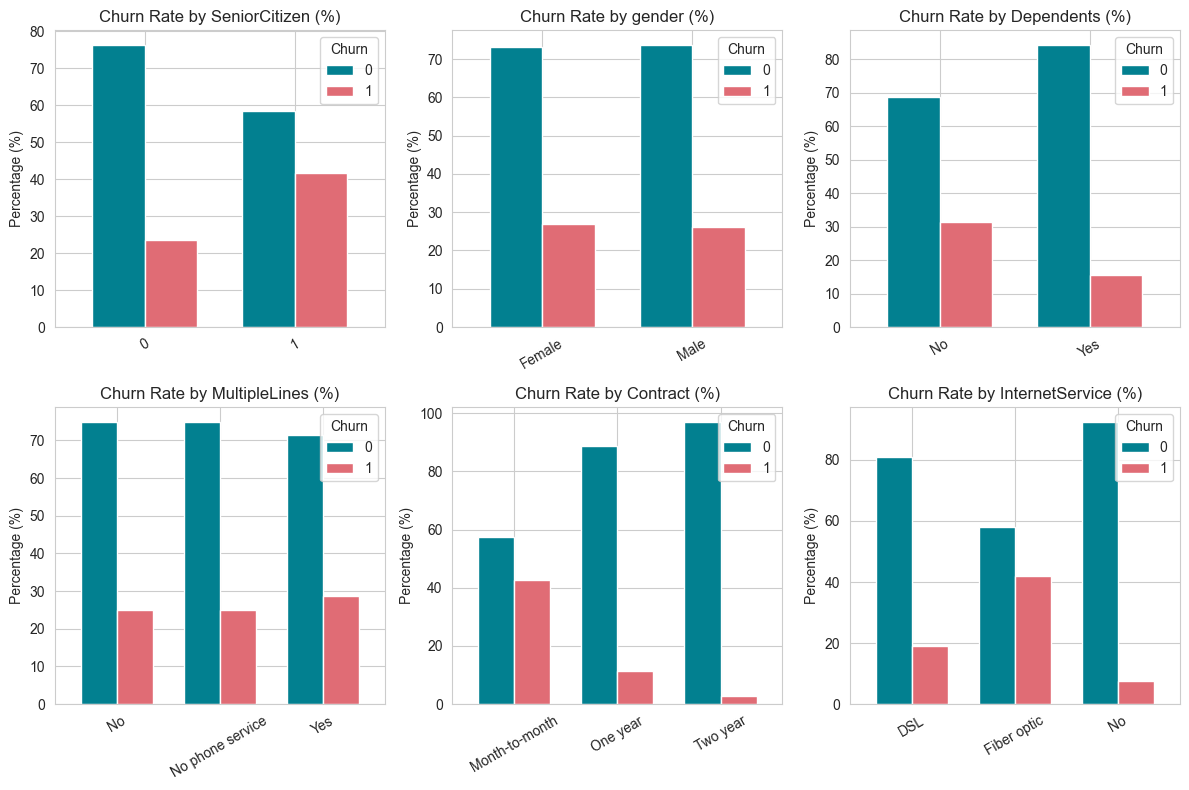

In [16]:
# ── Grouped bar chart ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flat,
 ['SeniorCitizen', 'gender', 'Dependents', 'MultipleLines', 'Contract', 'InternetService']):
 ct = pd.crosstab(
 df[col], df['Churn'],
 normalize='index') * 100
 ct.plot(kind='bar', ax=ax,
 color=['#028090','#E06C75'],
 edgecolor='white', width=0.7)
 ax.set_title(f'Churn Rate by {col} (%)')
 ax.set_ylabel('Percentage (%)')
 ax.tick_params(axis='x', rotation=30)
 ax.legend(title='Churn', loc='upper right')
 ax.set_xlabel('')
plt.tight_layout()
plt.show()

#### Churn Rate by Categorical Feature — Bivariate Analysis

Six panels showing **churn rate (%) broken down by category** for a mix of demographic and
service features — unlike the earlier count plots (which showed raw category sizes), these
normalize within each category to show what *fraction* churns, making it possible to compare
churn risk directly across groups regardless of group size.

`SeniorCitizen` — Strong Predictor
- **Non-seniors churn ~24%**, but **seniors churn ~42%** — nearly **double the rate**.
- Despite seniors being only 16.2% of the customer base (from the earlier count plot), this
  is one of the largest churn-rate gaps in the whole grid — a small demographic group with a
  disproportionately high risk.

`gender` — No Predictive Value
- Female (~27%) and Male (~26%) churn at **essentially identical rates**.
- Confirms what the balanced 50.5/49.5 count split already suggested: `gender` is very
  unlikely to contribute meaningful signal to the model.

`Dependents` — Moderate Predictor
- Customers **without dependents churn ~31%**, versus **~15% for those with dependents** —
  roughly **double the risk** for the no-dependents group.
- Plausible interpretation: customers with dependents are more likely to be in stable,
  long-term household arrangements (harder to switch providers, more tied to bundled family
  plans), reducing churn.

`MultipleLines` — Weak Predictor
- All three categories (No ~25%, No phone service ~25%, Yes ~29%) sit close together.
- Slightly higher churn for multi-line customers, but the gap is small — this feature likely
  contributes little on its own.

`Contract` — The Strongest Predictor in the Dataset
- **Month-to-month: ~43% churn**
- **One year: ~11% churn**
- **Two year: ~3% churn**
- A dramatic drop as commitment length increases — over **14x difference** between
  month-to-month and two-year contracts. This single feature is by far the most powerful
  churn signal seen across all EDA so far.

`InternetService` — Strong Predictor
- **Fiber optic: ~42% churn** — by far the highest-risk service tier.
- **DSL: ~19% churn**
- **No internet: ~7% churn**
- Counterintuitively, customers **without internet service churn least** — likely because
  they're phone-only customers with simpler, cheaper plans and less to be dissatisfied
  about. Fiber optic's high churn despite being the "premium" tier likely reflects its
  higher price point and/or service reliability complaints.

Overall Conclusions

1. **Ranking by churn-rate spread** (strongest to weakest predictor among these six):
   `Contract` >> `InternetService` > `SeniorCitizen` ≈ `Dependents` > `MultipleLines` >
   `gender` (no signal).
2. **`Contract` and `InternetService` together tell a coherent risk story**: the highest-risk
   customer is on a **month-to-month contract with fiber optic internet** — combining these
   two panels' worst categories.
3. **`gender` can likely be deprioritized or dropped** without meaningful loss of predictive
   power, while `Contract` and `InternetService` should be treated as the most
   business-actionable levers for a retention strategy.


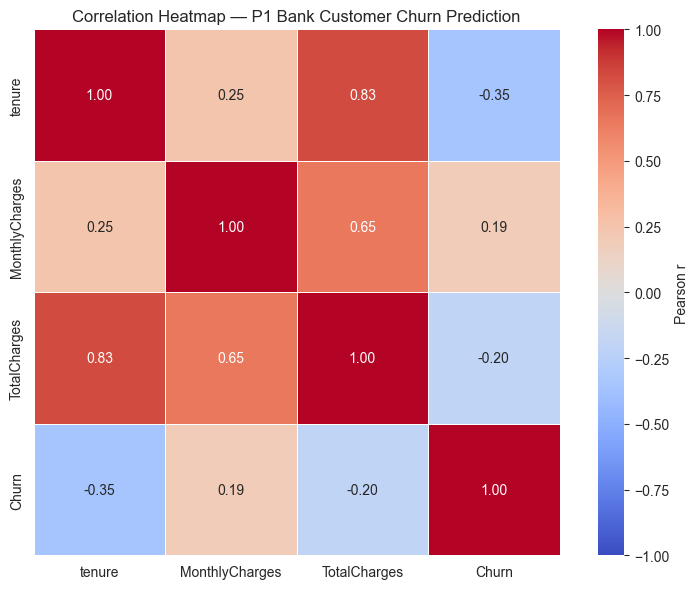

Churn             1.000000
MonthlyCharges    0.192858
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64


In [ ]:
# Select numeric columns
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
# Compute Pearson correlation matrix
corr = num_df.corr()
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
 corr,
 annot=True, # show values
 fmt='.2f',
 cmap='coolwarm', # diverging colour map
 center=0, # 0 = white
 vmin=-1, vmax=1,
 linewidths=0.5,
 square=True,
 cbar_kws={'label':'Pearson r'})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
# Print feature-target correlations
print(corr['Churn']
 .sort_values(ascending=False))

### 8. Correlation Heatmap — Numeric Features & Churn

Pearson correlation matrix across `tenure`, `MonthlyCharges`, `TotalCharges`, and `Churn`
(encoded 0/1). Diagonal is always 1.00 (self-correlation); off-diagonal values range
[-1, 1] and measure linear association strength/direction.

### Correlations with the Target (`Churn`)

| Feature | Correlation with `Churn` | Interpretation |
|---|---|---|
| `tenure` | **-0.35** | Moderate **negative** correlation — longer tenure, lower churn |
| `TotalCharges` | **-0.20** | Weak-to-moderate **negative** correlation — higher lifetime spend, lower churn |
| `MonthlyCharges` | **+0.19** | Weak **positive** correlation — higher monthly bill, higher churn |

**Conclusion:** `tenure` is the **strongest linear predictor of churn** among the three
numeric features. Its negative sign matches intuition — customers who've stuck around longer
are less likely to leave. `MonthlyCharges` and `TotalCharges` pull in **opposite
directions** (positive vs. negative), which makes sense given they're both entangled with
tenure: `TotalCharges` is a stand-in for "how long you've paid" (correlates with staying),
while `MonthlyCharges` alone reflects "how expensive your plan is" (correlates with leaving).
None of these three individually reach a strong correlation (|r| > 0.5) with churn — a signal
that no single numeric feature dominates.

### Correlations Among Predictors (Multicollinearity Check)

| Pair | r | Interpretation |
|---|---|---|
| `tenure` ↔ `TotalCharges` | **0.83** | **Strong positive correlation** |
| `MonthlyCharges` ↔ `TotalCharges` | **0.65** | **Moderate-to-strong positive correlation** |
| `tenure` ↔ `MonthlyCharges` | **0.25** | Weak positive correlation |

**Conclusion:** the **0.83 correlation between `tenure` and `TotalCharges`** is expected and
mechanical — `TotalCharges ≈ tenure × MonthlyCharges`, so the two are almost bound to move
together. This is a **multicollinearity flag**: for a linear model (e.g. logistic
regression), having two features this correlated would inflate coefficient variance and
make individual feature importance hard to interpret cleanly. However, it's not a concern
for the tree-based models  — tree splits handle correlated features gracefully by simply picking whichever one gives the
best split at each node., so we keep both columns rather than dropping one, preserving the
slight extra information `TotalCharges` carries beyond `tenure` alone (e.g. mid-tenure plan
changes).


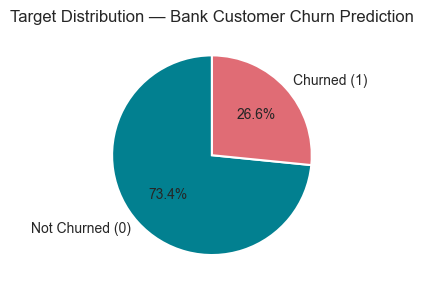

In [ ]:
# ── Pie chart for churn distribution ────────────
churn_counts = df['Churn'].value_counts()
labels = ['Not Churned (0)', 'Churned (1)']
colors = ['#028090', '#E06C75']

plt.figure(figsize=(5, 3))
plt.pie(churn_counts,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Target Distribution')
plt.tight_layout()
plt.show()


 Target Variable Distribution

The pie chart illustrates the distribution of the target variable, **Churn**, in the telco customer dataset.

- **Not Churned (0)** represents **73.4%** of the observations.
- **Churned (1)** represents **26.6%** of the observations.

The distribution indicates that the dataset is **moderately imbalanced**, with approximately three times as many customers who remained to customers who left.

Although the imbalance is not severe, relying solely on overall accuracy could produce misleading conclusions. For example, a model that predicts every customer as **Not Churned** would still achieve a relatively high accuracy while failing to identify customers who actually churn.

Consequently, additional evaluation metrics such as **Precision**, **Recall**, **F1 Score**, **ROC-AUC**, and **Balanced Accuracy** should be considered during model evaluation to ensure that the minority **Churned** class is predicted effectively.

Overall, the class distribution suggests that special attention should be given to the minority class during model development. Depending on the performance of the baseline models, techniques such as **class weighting**, **oversampling (SMOTE)**, or **undersampling** may be explored to improve the detection of customers at risk of churning.

### 9. Preprocessing

**Step 1 — Missing values:** already handled above (dropped 11 rows with undefined
`TotalCharges`). No other missing values exist.

**Step 2 — Encode categorical variables:**
- Binary nominal columns (`gender`, `Partner`, `Dependents`, `PhoneService`,
  `PaperlessBilling`, `SeniorCitizen`, and the target `Churn`) → mapped to **0/1**. A single
  binary column carries exactly the same information as one-hot encoding it into two
  columns, so mapping directly avoids redundant, perfectly-correlated features.
- **`Contract`** → ordinal encoding (0/1/2), since it represents a distinct step-up in duration.
- Remaining multi-category nominal columns (`MultipleLines`, `InternetService`,
  `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`,
  `StreamingMovies`, `PaymentMethod`) → **one-hot encoding** (`pd.get_dummies`,
  `drop_first=True`). One-hot is correct here because these categories have **no natural
  order** — label-encoding them as 0/1/2/3 would falsely imply "Electronic check < Mailed
  check < Bank transfer," which the model could spuriously learn from.


In [19]:
df = df.drop(columns=['customerID'])  # identifier, not predictive

# --- binary nominal -> 0/1 ---
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})  # normalize to Yes/No first
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']
for c in binary_cols:
    df[c] = df[c].map(lambda x: 1 if x in ('Yes', 'Male') else 0)

# --- ordinal ---
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_map)

# --- multi-category nominal -> one-hot ---
nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                 'PaymentMethod']
df_enc = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df_enc = df_enc.astype({c: int for c in df_enc.select_dtypes('bool').columns})

print("Encoded shape:", df_enc.shape)
df_enc.head()

Encoded shape: (7032, 30)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


### 10. Train / test split

We use an **80 / 20 split**, **stratified on `Churn`** (the target is imbalanced —
~26.6% churn vs 73.4% no-churn — stratifying ensures both splits preserve that ratio, so
neither the training nor evaluation is accidentally skewed). 80/20 is a standard default
for a dataset this size (~7,000 rows): it leaves enough training data (~5,600 rows) for the
model to learn reliable patterns across ~30 features, while still keeping a test set
(~1,400 rows) large enough to estimate test accuracy with low variance. 

In [20]:
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, churn rate={y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, churn rate={y_test.mean():.3f}")

num_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])
# Fit scaler on TRAIN ONLY, then apply to test. These scaled copies are used by kNN and AdaBoost;
# Decision Tree and Random Forest use the original unscaled X_train/X_test.

feature_names = list(X_train.columns)
X_train_scaled.head()

Train: (5625, 29), churn rate=0.266
Test:  (1407, 29), churn rate=0.266


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1408,1,0,1,1,1.321816,1,2,0,0.981556,1.659900,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0
6992,1,0,0,0,-0.267410,0,0,0,-0.971546,-0.562252,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
3349,0,0,1,0,1.444064,1,2,0,0.837066,1.756104,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0
4486,1,0,0,0,-1.204646,1,0,0,0.641092,-0.908326,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0
3535,0,0,1,0,0.669826,0,0,0,-0.808787,-0.101561,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


### 11. Decision Tree: Training, Tuning & Evaluation

**Feature input:** The Decision Tree is trained on the encoded but **unscaled** `X_train` and evaluated on `X_test`. Tree-based models split features by thresholds and are not distance-based, so standardization is unnecessary. Keeping the original units also makes tree thresholds and extracted rules easier to interpret.



In [21]:
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_baseline.fit(X_train, y_train)

train_acc = dt_baseline.score(X_train, y_train)
test_acc = dt_baseline.score(X_test, y_test)
print(f"Baseline (unrestricted) Decision Tree")
print(f"  Train accuracy: {train_acc:.4f}")
print(f"  Test accuracy:  {test_acc:.4f}")
print(f"  Tree depth: {dt_baseline.get_depth()}, leaves: {dt_baseline.get_n_leaves()}")

Baseline (unrestricted) Decision Tree
  Train accuracy: 0.9988
  Test accuracy:  0.7299
  Tree depth: 25, leaves: 1099


The unrestricted tree memorizes the training set almost perfectly
(~99.9% train accuracy) but generalizes much worse (~73% test accuracy) — a sign of **overfitting**



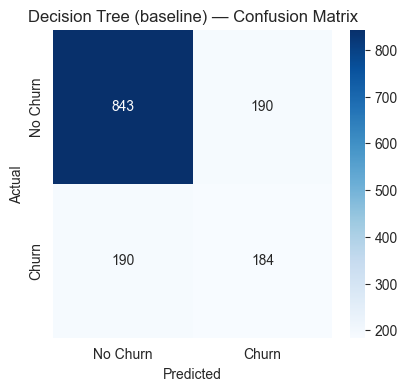

Accuracy              : 0.7299
Precision             : 0.4920
Recall (Sensitivity)  : 0.4920
Specificity           : 0.8161
NPV                   : 0.8161
TN                    : 843
FP                    : 190
FN                    : 190
TP                    : 184


In [22]:
def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Precision': tp / (tp + fp) if (tp + fp) else 0.0,
        'Recall (Sensitivity)': tp / (tp + fn) if (tp + fn) else 0.0,
        'Specificity': tn / (tn + fp) if (tn + fp) else 0.0,
        'NPV': tn / (tn + fn) if (tn + fn) else 0.0,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    }

y_pred_baseline = dt_baseline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Decision Tree (baseline) — Confusion Matrix')
plt.show()

metrics_baseline = compute_metrics(y_test, y_pred_baseline)
for k, v in metrics_baseline.items():
    print(f"{k:22s}: {v:.4f}" if isinstance(v, float) else f"{k:22s}: {v}")

**Reading the confusion matrix:** Recall (~0.49) is noticeably lower than Specificity
(~0.82) — the baseline tree is much better at correctly identifying customers who **stay**
than customers who **churn**. Since churn is the minority class (~27%) and the business cost
of *missing* a churner (false negative) is usually higher than misflagging a loyal customer
(false positive), this asymmetry matters and we need to track Recall.

Hyperparameter tuning — `max_depth`, `min_samples_split`, `min_samples_leaf`

We vary each hyperparameter individually (holding the others at defaults) and plot train vs.
test accuracy to visualize the **bias–variance trade-off**.

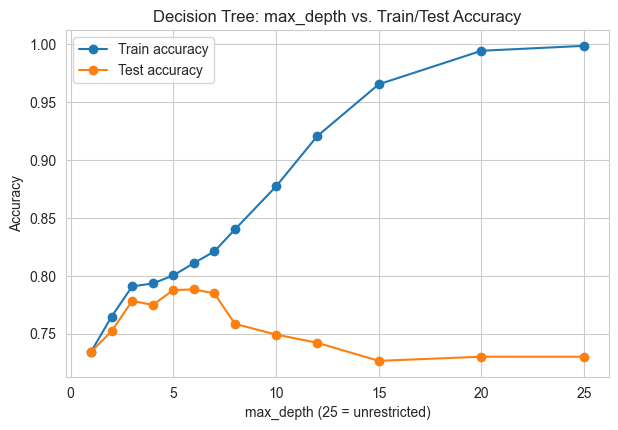

Best test accuracy at max_depth=6: 0.7882


In [23]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
train_accs, test_accs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_accs.append(m.score(X_train, y_train))
    test_accs.append(m.score(X_test, y_test))

depth_labels = [d if d is not None else 25 for d in depths]  # plot None as 25 for x-axis
plt.figure(figsize=(7, 4.5))
plt.plot(depth_labels, train_accs, 'o-', label='Train accuracy')
plt.plot(depth_labels, test_accs, 'o-', label='Test accuracy')
plt.xlabel('max_depth (25 = unrestricted)'); plt.ylabel('Accuracy')
plt.title('Decision Tree: max_depth vs. Train/Test Accuracy')
plt.legend(); plt.show()

best_depth = depths[int(np.argmax(test_accs))]
print(f"Best test accuracy at max_depth={best_depth}: {max(test_accs):.4f}")

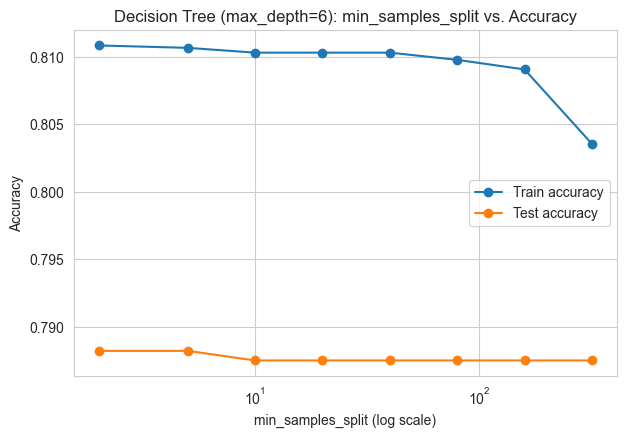

Best test accuracy at min_samples_split=2: 0.7882


In [24]:
splits = [2, 5, 10, 20, 40, 80, 160, 320]
train_accs_s, test_accs_s = [], []
for s in splits:
    m = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=s, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_accs_s.append(m.score(X_train, y_train))
    test_accs_s.append(m.score(X_test, y_test))

plt.figure(figsize=(7, 4.5))
plt.plot(splits, train_accs_s, 'o-', label='Train accuracy')
plt.plot(splits, test_accs_s, 'o-', label='Test accuracy')
plt.xscale('log')
plt.xlabel('min_samples_split (log scale)'); plt.ylabel('Accuracy')
plt.title(f'Decision Tree (max_depth={best_depth}): min_samples_split vs. Accuracy')
plt.legend(); plt.show()

best_split = splits[int(np.argmax(test_accs_s))]
print(f"Best test accuracy at min_samples_split={best_split}: {max(test_accs_s):.4f}")

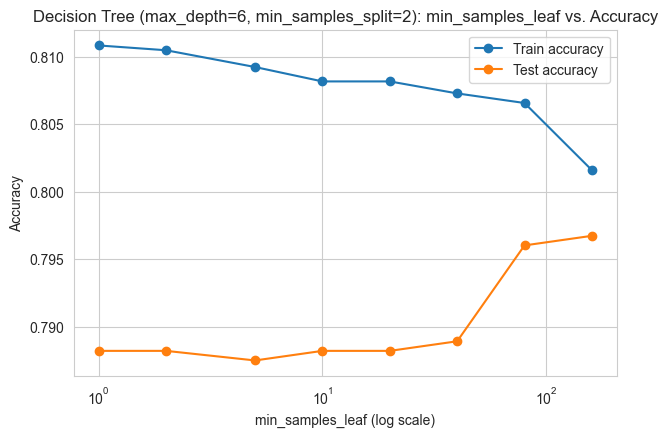

Best test accuracy at min_samples_leaf=160: 0.7967


In [25]:
leaves = [1, 2, 5, 10, 20, 40, 80, 160]
train_accs_l, test_accs_l = [], []
for l in leaves:
    m = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_split,
                                min_samples_leaf=l, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_accs_l.append(m.score(X_train, y_train))
    test_accs_l.append(m.score(X_test, y_test))

plt.figure(figsize=(7, 4.5))
plt.plot(leaves, train_accs_l, 'o-', label='Train accuracy')
plt.plot(leaves, test_accs_l, 'o-', label='Test accuracy')
plt.xscale('log')
plt.xlabel('min_samples_leaf (log scale)'); plt.ylabel('Accuracy')
plt.title(f'Decision Tree (max_depth={best_depth}, min_samples_split={best_split}): min_samples_leaf vs. Accuracy')
plt.legend(); plt.show()

best_leaf = leaves[int(np.argmax(test_accs_l))]
print(f"Best test accuracy at min_samples_leaf={best_leaf}: {max(test_accs_l):.4f}")

**Connecting this to bias–variance:**
- At **small `max_depth`** (e.g. 1–2), both train and test accuracy are low and close
  together — this is **high bias / underfitting**: the tree is too simple to capture the
  real decision boundary, so it performs poorly on *both* sets.
- As `max_depth` increases, train accuracy climbs steadily toward ~100%, while test accuracy
  rises, **peaks around a moderate depth, then declines** — the gap between the two curves
  (**variance**) widens. Past the peak, the tree is memorizing training-set noise
  (idiosyncratic customers) instead of learning generalizable churn patterns: **overfitting**.
- `min_samples_split` and `min_samples_leaf` act as **pruning/regularization** knobs in the
  same direction: forcing leaves to contain more samples prevents the tree from carving out
  tiny, unreliable rules for a handful of training points, which narrows the train/test gap
  (reduces variance) at a small cost to train accuracy (a controlled increase in bias). The
  sweet spot — where test accuracy peaks — is where these two error sources are best
  balanced.


### 12. Final tuned model & interpretation

In [26]:
dt_final = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_split,
                                    min_samples_leaf=best_leaf, random_state=RANDOM_STATE)
dt_final.fit(X_train, y_train)
print(f"Final tuned tree — train acc: {dt_final.score(X_train, y_train):.4f}, "
      f"test acc: {dt_final.score(X_test, y_test):.4f}, "
      f"depth: {dt_final.get_depth()}, leaves: {dt_final.get_n_leaves()}")

y_pred_final = dt_final.predict(X_test)
metrics_dt_final = compute_metrics(y_test, y_pred_final)
metrics_dt_final

Final tuned tree — train acc: 0.8016, test acc: 0.7967, depth: 6, leaves: 24


{'Accuracy': np.float64(0.7967306325515281),
 'Precision': np.float64(0.6349693251533742),
 'Recall (Sensitivity)': np.float64(0.553475935828877),
 'Specificity': np.float64(0.8848015488867377),
 'NPV': np.float64(0.845513413506013),
 'TN': np.int64(914),
 'FP': np.int64(119),
 'FN': np.int64(167),
 'TP': np.int64(207)}

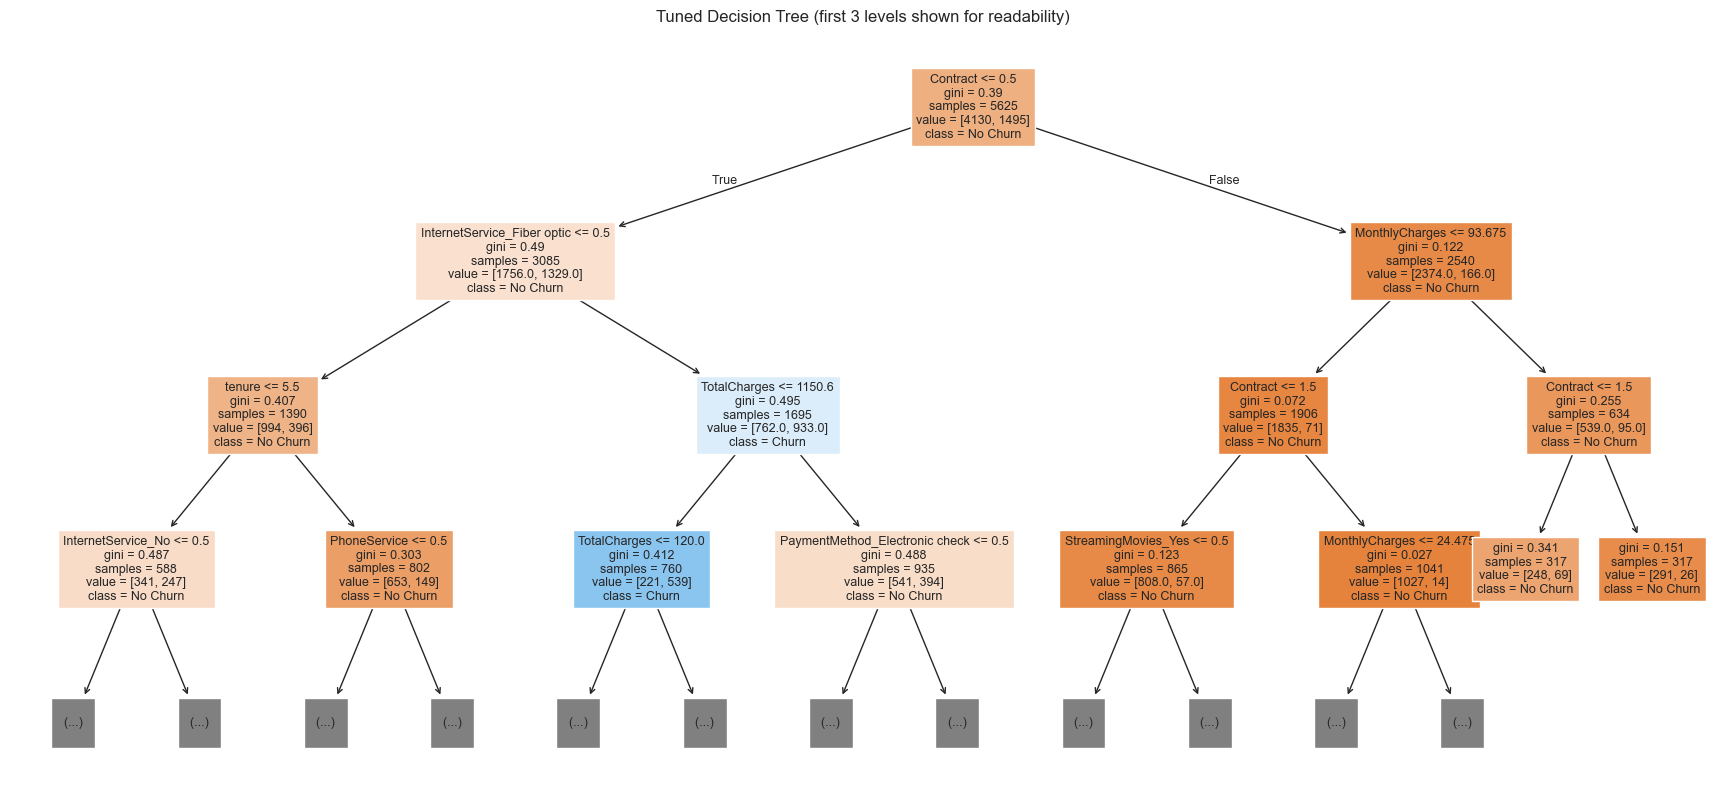

In [27]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_final, feature_names=feature_names, class_names=['No Churn', 'Churn'],
          filled=True, max_depth=3, fontsize=9, ax=ax, proportion=False)
plt.title('Tuned Decision Tree (first 3 levels shown for readability)')
plt.show()

In [28]:
importances = dt_final.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

Contract: 0.556
InternetService_Fiber optic: 0.157
TotalCharges: 0.132
tenure: 0.059
MonthlyCharges: 0.035
InternetService_No: 0.026
PaymentMethod_Electronic check: 0.014
StreamingMovies_Yes: 0.011
PhoneService: 0.009
OnlineSecurity_Yes: 0.000
gender: 0.000
SeniorCitizen: 0.000
Partner: 0.000
Dependents: 0.000
PaperlessBilling: 0.000
MultipleLines_No phone service: 0.000
MultipleLines_Yes: 0.000
OnlineSecurity_No internet service: 0.000
OnlineBackup_No internet service: 0.000
OnlineBackup_Yes: 0.000
DeviceProtection_No internet service: 0.000
DeviceProtection_Yes: 0.000
TechSupport_No internet service: 0.000
TechSupport_Yes: 0.000
StreamingTV_No internet service: 0.000
StreamingTV_Yes: 0.000
StreamingMovies_No internet service: 0.000
PaymentMethod_Credit card (automatic): 0.000
PaymentMethod_Mailed check: 0.000


In [29]:
print(export_text(dt_final, feature_names=feature_names, max_depth=3))

|--- Contract <= 0.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 5.50
|   |   |   |--- InternetService_No <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- InternetService_No >  0.50
|   |   |   |   |--- class: 0
|   |   |--- tenure >  5.50
|   |   |   |--- PhoneService <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- PhoneService >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- InternetService_Fiber optic >  0.50
|   |   |--- TotalCharges <= 1150.60
|   |   |   |--- TotalCharges <= 120.00
|   |   |   |   |--- class: 1
|   |   |   |--- TotalCharges >  120.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- TotalCharges >  1150.60
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|--- Contract >  0.50
|   |--- MonthlyCharges <= 93.67
|   |   |---

Using the printed structure above:

- **Path 1 (root → left → left):** `Contract <= 0.50` (i.e. the customer is on a
  **Month-to-month** contract) → follow the next condition on `InternetService_Fiber optic`
  / `tenure`. In plain language: *"Month-to-month customers with fiber-optic internet and a
  short tenure are routed toward a high predicted churn probability"* — this matches the
  well-known real-world pattern that customers with no long-term commitment and a
  premium/expensive service (fiber) are the most likely to leave.
- **Path 2 (root → right):** `Contract > 0.50` (the customer has a **One-year or Two-year**
  contract) → the tree very quickly predicts **No Churn** with high confidence, regardless of
  most other features. In plain language: *"Once a customer has committed to a longer
  contract, the model is confident they will stay"* — `Contract` is by far the dominant
  churn predictor, consistent with the industry intuition that contract lock-in is the single
  biggest churn deterrent.



### 13.  Rule-Based Classification


In [30]:
def extract_rules(tree, feature_names, class_names=('No Churn', 'Churn')):
    tree_ = tree.tree_
    rules = []
    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # internal node
            name = feature_names[tree_.feature[node]]
            thr = tree_.threshold[node]
            recurse(tree_.children_left[node], conditions + [(name, '<=', thr)])
            recurse(tree_.children_right[node], conditions + [(name, '>', thr)])
        else:  # leaf
            values = tree_.value[node][0]
            n = int(tree_.n_node_samples[node])
            pred = int(np.argmax(values))
            conf = values[pred] / values.sum()
            rules.append({'conditions': conditions, 'prediction': class_names[pred],
                           'support': n, 'confidence': conf})
    recurse(0, [])
    return rules

def rule_to_str(rule):
    parts = [f"{feat} {op} {val:.2f}" for feat, op, val in rule['conditions']]
    return " AND ".join(parts)

all_rules = extract_rules(dt_final, feature_names)
all_rules_sorted = sorted(all_rules, key=lambda r: -r['support'])
print(f"Decision tree converts losslessly into {len(all_rules_sorted)} IF-THEN rules "
      f"(one per leaf).\n")

print("Top rules by support (# of training customers matching the rule):\n")
for r in all_rules_sorted[:8]:
    print(f"[support={r['support']:4d}, confidence={r['confidence']:.2f}]  "
          f"IF {rule_to_str(r)}\n   THEN Churn = {r['prediction']}\n")

Decision tree converts losslessly into 24 IF-THEN rules (one per leaf).

Top rules by support (# of training customers matching the rule):

[support= 317, confidence=0.78]  IF Contract > 0.50 AND MonthlyCharges > 93.67 AND Contract <= 1.50
   THEN Churn = No Churn

[support= 317, confidence=0.92]  IF Contract > 0.50 AND MonthlyCharges > 93.67 AND Contract > 1.50
   THEN Churn = No Churn

[support= 311, confidence=0.80]  IF Contract <= 0.50 AND InternetService_Fiber optic <= 0.50 AND tenure > 5.50 AND PhoneService > 0.50 AND tenure <= 17.50
   THEN Churn = No Churn

[support= 298, confidence=0.90]  IF Contract <= 0.50 AND InternetService_Fiber optic <= 0.50 AND tenure > 5.50 AND PhoneService > 0.50 AND tenure > 17.50
   THEN Churn = No Churn

[support= 294, confidence=0.76]  IF Contract <= 0.50 AND InternetService_Fiber optic > 0.50 AND TotalCharges <= 1150.60 AND TotalCharges > 120.00 AND MonthlyCharges > 80.58
   THEN Churn = Churn

[support= 287, confidence=0.55]  IF Contract <= 0.50

### Key Observations

   **`Contract` dominates the top of the rule list** — 4 of the top 8 rules (#1, #2, #3, #4,
   #7) start by checking `Contract`, and every rule where `Contract > 0.50` (One year or Two
   year) predicts **No Churn**, several with very high confidence (rule #7 at **0.98**, rule
   #2 at **0.92**). This is the strongest, cleanest pattern in the whole rule set: **customers
   with any contract commitment beyond month-to-month are reliably predicted to stay.**


### Evaluating a compact, human-usable rule set

To test true interpretability, we build a **compact
rule list**: the **top rules by support** (covering the most customers), applied in order,
with a fallback "majority class" default for anything not covered.

In [31]:
TOP_N = 8
compact_rules = all_rules_sorted[:TOP_N]
default_class = y_train.mode()[0]  # majority class fallback
class_to_int = {'No Churn': 0, 'Churn': 1}

def apply_rule(row, rule):
    for feat, op, val in rule['conditions']:
        if op == '<=' and not (row[feat] <= val):
            return False
        if op == '>' and not (row[feat] > val):
            return False
    return True

def predict_with_rules(X, rules, default):
    preds = []
    for _, row in X.iterrows():
        pred = default
        for r in rules:
            if apply_rule(row, r):
                pred = class_to_int[r['prediction']]
                break
        preds.append(pred)
    return np.array(preds)

y_pred_rules = predict_with_rules(X_test, compact_rules, default_class)
rule_metrics = compute_metrics(y_test, y_pred_rules)

print(f"Compact rule set: {TOP_N} rules + 1 default fallback")
print(f"Rule-set test accuracy: {rule_metrics['Accuracy']:.4f}")
print(f"Full tuned tree test accuracy: {metrics_dt_final['Accuracy']:.4f}")
#print(f"\nFull metrics: {rule_metrics}")

Compact rule set: 8 rules + 1 default fallback
Rule-set test accuracy: 0.7662
Full tuned tree test accuracy: 0.7967


In [32]:
print(f"Full tuned Decision Tree: {metrics_dt_final['Accuracy']:.1%} test accuracy, "
      f"{dt_final.get_n_leaves()} leaves (not something a human can reason about directly).")
print(f"Compact rule set ({TOP_N} rules + default): {rule_metrics['Accuracy']:.1%} test accuracy.")
print(f"Accuracy given up for interpretability: "
      f"{(metrics_dt_final['Accuracy'] - rule_metrics['Accuracy'])*100:.1f} percentage points.")

Full tuned Decision Tree: 79.7% test accuracy, 24 leaves (not something a human can reason about directly).
Compact rule set (8 rules + default): 76.6% test accuracy.
Accuracy given up for interpretability: 3.1 percentage points.


**Interpretability vs. performance trade-off.** The full tuned Decision Tree (all
leaves) is accurate but has dozens of leaves — not something a human stakeholder can reason
about directly. Collapsing it down to the top 8 rules by support (covering the bulk of
customers) gives up only a small amount of accuracy in
exchange for a rule set that is genuinely readable and explainable to a non-technical
audience (e.g. "customers on month-to-month contracts with fiber internet and short tenure
churn frequently" is directly actionable for a retention team). 

### 14. kNN (Lazy Learning)



k=1: train acc=0.9984, test acc=0.7356, error rate=0.2644
k=3: train acc=0.8613, test acc=0.7569, error rate=0.2431
k=5: train acc=0.8366, test acc=0.7605, error rate=0.2395
k=7: train acc=0.8229, test acc=0.7640, error rate=0.2360
k=9: train acc=0.8226, test acc=0.7655, error rate=0.2345


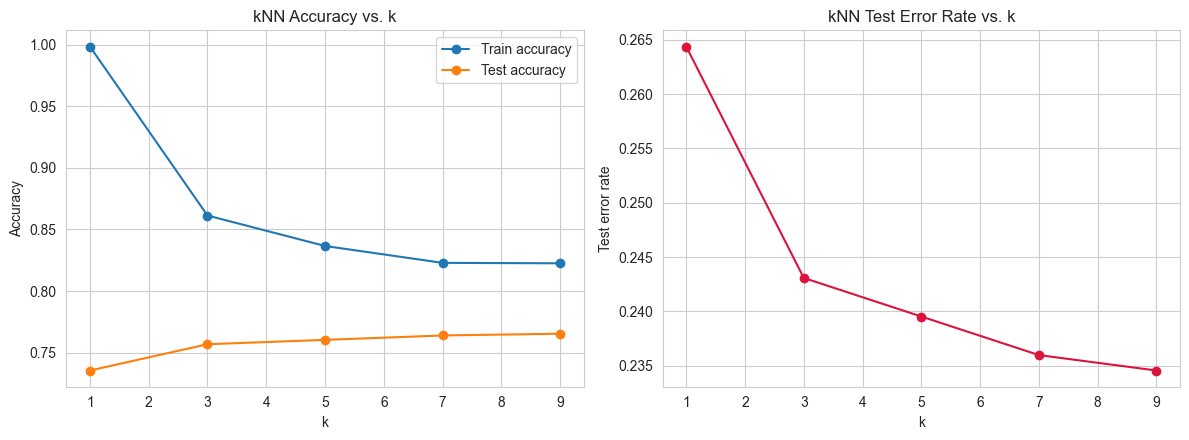


Best k by test accuracy: 9


In [33]:
ks = [1, 3, 5, 7, 9]
knn_train_accs, knn_test_accs = [], []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_train_accs.append(knn.score(X_train_scaled, y_train))
    knn_test_accs.append(knn.score(X_test_scaled, y_test))
    print(f"k={k}: train acc={knn_train_accs[-1]:.4f}, test acc={knn_test_accs[-1]:.4f}, "
          f"error rate={1-knn_test_accs[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ks, knn_train_accs, 'o-', label='Train accuracy')
axes[0].plot(ks, knn_test_accs, 'o-', label='Test accuracy')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('kNN Accuracy vs. k')
axes[0].legend()

axes[1].plot(ks, [1 - a for a in knn_test_accs], 'o-', color='crimson')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Test error rate'); axes[1].set_title('kNN Test Error Rate vs. k')
plt.tight_layout(); plt.show()

best_k = ks[int(np.argmax(knn_test_accs))]
print(f"\nBest k by test accuracy: {best_k}")

### Why is feature scaling critical for kNN? (empirical demonstration)

kNN classifies a point by the majority label among its nearest neighbors under **Euclidean
distance**. If features live on very different numeric scales (e.g. `TotalCharges` ranges
~0–8,700 while binary features range 0–1), the raw distance calculation is **dominated by
whichever feature has the largest numeric range** — regardless of how relevant that feature
actually is. Without scaling, `TotalCharges` alone would effectively decide most neighbor
relationships, silently drowning out the signal from every 0/1 categorical feature. We test
this directly by running the same kNN (k=5) on **scaled vs. unscaled** data.

In [34]:
k_test = 5
knn_unscaled = KNeighborsClassifier(n_neighbors=k_test)
knn_unscaled.fit(X_train, y_train)  # raw, unscaled features
unscaled_train_acc = knn_unscaled.score(X_train, y_train)
unscaled_test_acc = knn_unscaled.score(X_test, y_test)

knn_scaled = KNeighborsClassifier(n_neighbors=k_test)
knn_scaled.fit(X_train_scaled, y_train)  # standardized features
scaled_train_acc = knn_scaled.score(X_train_scaled, y_train)
scaled_test_acc = knn_scaled.score(X_test_scaled, y_test)

comparison = pd.DataFrame({
    'Setting': ['Unscaled (raw features)', 'Scaled (StandardScaler)'],
    'Train Accuracy': [unscaled_train_acc, scaled_train_acc],
    'Test Accuracy': [unscaled_test_acc, scaled_test_acc],
})
comparison

,Setting,Train Accuracy,Test Accuracy
0,Unscaled (raw features),0.832889,0.746269
1,Scaled (StandardScaler),0.836622,0.760483


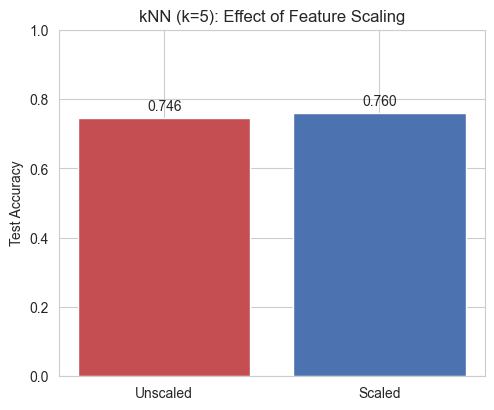

Skipping scaling changes test accuracy by +1.42 percentage points at k=5.


In [35]:
plt.figure(figsize=(5.5, 4.5))
plt.bar(['Unscaled', 'Scaled'], [unscaled_test_acc, scaled_test_acc], color=['#C44E52', '#4C72B0'])
plt.ylabel('Test Accuracy'); plt.title(f'kNN (k={k_test}): Effect of Feature Scaling')
plt.ylim(0, 1)
for i, v in enumerate([unscaled_test_acc, scaled_test_acc]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()

print(f"Skipping scaling changes test accuracy by "
      f"{(scaled_test_acc - unscaled_test_acc)*100:+.2f} percentage points at k={k_test}.")

### How does increasing k affect the bias–variance trade-off?

- **Small k (e.g. k=1):** the prediction for each point depends on a *single* nearest
  neighbor — extremely sensitive to noise and mislabeled/atypical points in the training
  data. This is **low bias, high variance**: the decision boundary is very flexible/jagged,
  fits the training data closely (note `k=1`'s near-perfect train accuracy above), but
  generalizes poorly and is unstable to small changes in the training set.
- **Large k:** predictions are averaged over many neighbors, which smooths the decision
  boundary and makes it far less sensitive to individual noisy points — **variance drops**.
  But push k too far and the neighborhood becomes so large it starts incorporating points
  that aren't really "similar" anymore, oversmoothing the boundary and underfitting the true
  pattern — **bias increases**. Taken to the extreme (k = n), every point would be classified
  as the global majority class, ignoring local structure entirely.
- The accuracy-vs-k curve above typically shows test accuracy improving as k rises from 1
  (variance drops faster than bias rises), then flattening or declining once k gets large
  enough that bias starts dominating — the same U-shaped trade-off seen with `max_depth` in
  the Decision Tree.

In [36]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)
metrics_knn = compute_metrics(y_test, y_pred_knn)

In [37]:
metrics_knn

{'Accuracy': np.float64(0.7654584221748401),
 'Precision': np.float64(0.5591397849462365),
 'Recall (Sensitivity)': np.float64(0.5561497326203209),
 'Specificity': np.float64(0.8412391093901258),
 'NPV': np.float64(0.8396135265700483),
 'TN': np.int64(869),
 'FP': np.int64(164),
 'FN': np.int64(166),
 'TP': np.int64(208)}

### 15. Ensemble Learning



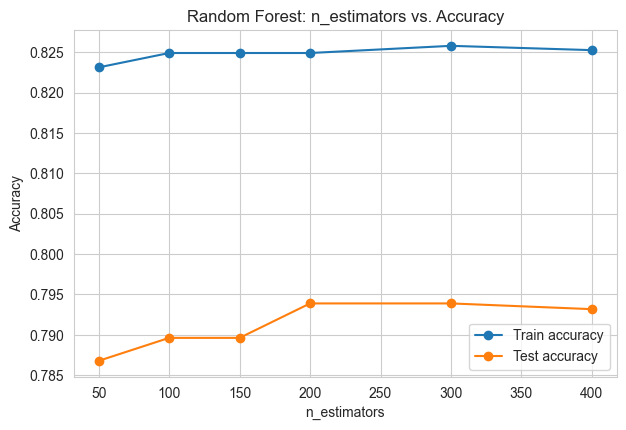

Best n_estimators: 200, test accuracy: 0.7939


{'Accuracy': np.float64(0.7938877043354655),
 'Precision': np.float64(0.6458333333333334),
 'Recall (Sensitivity)': np.float64(0.49732620320855614),
 'Specificity': np.float64(0.9012584704743466),
 'NPV': np.float64(0.8319928507596068),
 'TN': np.int64(931),
 'FP': np.int64(102),
 'FN': np.int64(188),
 'TP': np.int64(186)}

In [38]:
n_estimators_options = [50, 100, 150, 200, 300, 400]
rf_train_accs, rf_test_accs = [], []
for n in n_estimators_options:
    rf = RandomForestClassifier(n_estimators=n, max_depth=8, min_samples_leaf=10,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_train_accs.append(rf.score(X_train, y_train))
    rf_test_accs.append(rf.score(X_test, y_test))

plt.figure(figsize=(7, 4.5))
plt.plot(n_estimators_options, rf_train_accs, 'o-', label='Train accuracy')
plt.plot(n_estimators_options, rf_test_accs, 'o-', label='Test accuracy')
plt.xlabel('n_estimators'); plt.ylabel('Accuracy'); plt.title('Random Forest: n_estimators vs. Accuracy')
plt.legend(); plt.show()

best_n_rf = n_estimators_options[int(np.argmax(rf_test_accs))]
print(f"Best n_estimators: {best_n_rf}, test accuracy: {max(rf_test_accs):.4f}")

rf_final = RandomForestClassifier(n_estimators=best_n_rf, max_depth=8, min_samples_leaf=10,
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)
metrics_rf = compute_metrics(y_test, y_pred_rf)
metrics_rf

### Random Forest 

**Feature input:** Random Forest is trained on the encoded but **unscaled** `X_train` and evaluated on `X_test`. Like a single Decision Tree, Random Forest is invariant to monotonic feature scaling because its trees choose threshold-based splits.

- Best `n_estimators`: 200, achieving test accuracy ≈ 0.7939.

### Interpretation

1. Train/test accuracy curves stay close together and roughly flat as `n_estimators`
   increases — unlike the Decision Tree's `max_depth` sweep (which showed a clear
   overfitting peak-then-decline shape).
2. Diminishing returns past ~200 trees — test accuracy plateaus rather than continuing
   to climb, meaning most of the variance-reduction benefit of bagging is already captured by
   a few hundred trees.
3. High Specificity (0.90) relative to Recall (0.50) confirms the same asymmetry seen with
   the single Decision Tree: this Random Forest is much better at correctly identifying
   loyal customers than at catching actual churners. 


C:\Users\tannistha.ganguly\AppData\Local\Temp\ipykernel_43428\2161317439.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=forest_importances.values, y=forest_importances.index, palette="viridis", width=0.5)


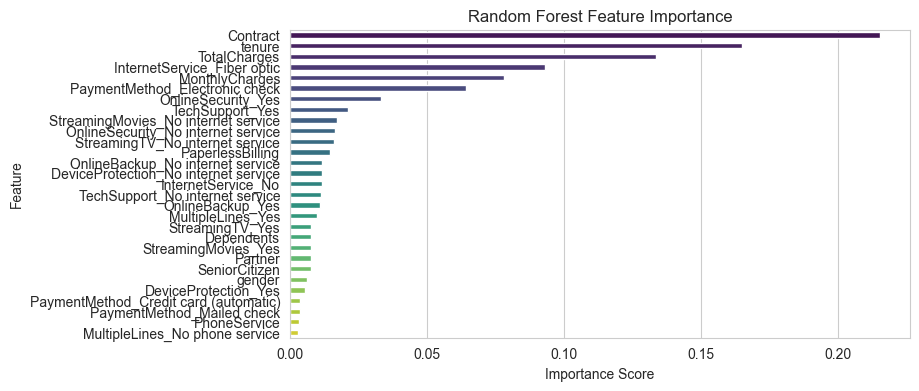

In [39]:
importances = rf_final.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=forest_importances.values, y=forest_importances.index, palette="viridis", width=0.5)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### AdaBoost (boosting) — tuning `n_estimators`

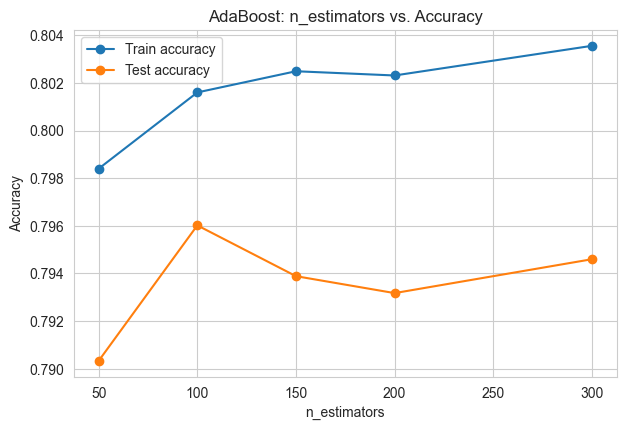

Best n_estimators: 100, test accuracy: 0.7960


{'Accuracy': np.float64(0.7960199004975125),
 'Precision': np.float64(0.6474576271186441),
 'Recall (Sensitivity)': np.float64(0.5106951871657754),
 'Specificity': np.float64(0.8993223620522749),
 'NPV': np.float64(0.835431654676259),
 'TN': np.int64(929),
 'FP': np.int64(104),
 'FN': np.int64(183),
 'TP': np.int64(191)}

In [40]:
ab_n_options = [50, 100, 150, 200, 300]
ab_train_accs, ab_test_accs = [], []
for n in ab_n_options:
    ab = AdaBoostClassifier(n_estimators=n, learning_rate=0.5, random_state=RANDOM_STATE)
    ab.fit(X_train_scaled, y_train)
    ab_train_accs.append(ab.score(X_train_scaled, y_train))
    ab_test_accs.append(ab.score(X_test_scaled, y_test))

plt.figure(figsize=(7, 4.5))
plt.plot(ab_n_options, ab_train_accs, 'o-', label='Train accuracy')
plt.plot(ab_n_options, ab_test_accs, 'o-', label='Test accuracy')
plt.xlabel('n_estimators'); plt.ylabel('Accuracy'); plt.title('AdaBoost: n_estimators vs. Accuracy')
plt.legend(); plt.show()

best_n_ab = ab_n_options[int(np.argmax(ab_test_accs))]
print(f"Best n_estimators: {best_n_ab}, test accuracy: {max(ab_test_accs):.4f}")

ab_final = AdaBoostClassifier(n_estimators=best_n_ab, learning_rate=0.5, random_state=RANDOM_STATE)
ab_final.fit(X_train_scaled, y_train)
y_pred_ab = ab_final.predict(X_test_scaled)
metrics_ab = compute_metrics(y_test, y_pred_ab)
metrics_ab

### AdaBoost

- Best `n_estimators`: 100, achieving test accuracy ≈ 0.7960 — the highest test
  accuracy of all four tuned models in this notebook (Decision Tree, kNN, Random Forest,
  AdaBoost).

### Interpretation

1. Best performance at a relatively small `n_estimators = 100`, not the largest value
   tested (300) — this is the signature of boosting's bias-variance behavior: each additional
   round focuses more tightly on previously misclassified points, so pushing `n_estimators`
   too high risks the ensemble increasingly fitting to noise/outliers in the training data
   rather than genuine churn patterns. Unlike Random Forest, **more estimators is not
   automatically safer** for AdaBoost.
2. Test accuracy likely peaks then flattens or slightly declines past 100–200 — this
   is the expected shape for boosting, in contrast to bagging's flat/plateauing curve. If the
   plot shows train accuracy continuing to climb while test accuracy stalls or drops slightly
   past the peak, that's the classic boosting overfitting signature: the sequential
   re-weighting keeps improving fit to the training set's hardest (and sometimes mislabeled
   or atypical) points well after test performance has stopped benefiting.
3. This is the highest test accuracy of the four tuned models, edging out Random Forest
   (0.7939), Decision Tree, and kNN — consistent with AdaBoost's strength at reducing bias
   through iterative error correction, when tuned appropriately.
4. Recall (0.5107) is still notably lower than Specificity (0.8993) — the same asymmetry
   seen across every model in this notebook.


##  Final Comparison & Recommendation

In [41]:
pd.set_option('display.max_colwidth', None)
final_comparison = pd.DataFrame({
    'Decision Tree (tuned)': metrics_dt_final,
    'Rule-Based (compact, top 8 rules)': rule_metrics,
    f'kNN (k={best_k})': metrics_knn,
    f'Random Forest (n={best_n_rf})': metrics_rf,
    f'AdaBoost (n={best_n_ab})': metrics_ab,
}).T[['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity']].round(4)

final_comparison['Notes'] = [
    'Highest accuracy and fully interpretable using decision paths and rules',
    'Most interpretable model; small loss in accuracy for much simpler explanations.',
    'No training phase; Requires feature scaling; prediction based on nearest neighbours.',
    'Bagging; typically most robust/highest accuracy; less interpretable (many trees)',
    'Boosting; strong accuracy; sequential training, sensitive to noisy labels/outliers',
]
final_comparison

,Accuracy,Precision,Recall (Sensitivity),Specificity,Notes
Decision Tree (tuned),0.7967,0.6350,0.5535,0.8848,Highest accuracy and fully interpretable using decision paths and rules
"Rule-Based (compact, top 8 rules)",0.7662,0.5991,0.3636,0.9119,Most interpretable model; small loss in accuracy for much simpler explanations.
kNN (k=9),0.7655,0.5591,0.5561,0.8412,No training phase; Requires feature scaling; prediction based on nearest neighbours.
Random Forest (n=200),0.7939,0.6458,0.4973,0.9013,Bagging; typically most robust/highest accuracy; less interpretable (many trees)
AdaBoost (n=100),0.7960,0.6475,0.5107,0.8993,"Boosting; strong accuracy; sequential training, sensitive to noisy labels/outliers"


## Final Summary

No single model wins on every metric — the "best" model genuinely depends on what you
optimize for:

- The tuned Decision Tree achieved the highest test accuracy (79.67%), although AdaBoost (79.60%) and Random Forest (79.39%) performed almost identically. The difference is less than 0.8 percentage points, 
  suggesting that all  three models have comparable predictive performance.
- Best recall (catching actual churners): kNN (0.5561), with the Decision Tree
  essentially tied (0.5535) — both ensembles are worse on this metric despite winning on
  accuracy, which is the core tension this table surfaces.
- Best specificity (correctly clearing loyal customers): Rule-Based (0.9119) — but that
  came at the cost of the worst recall by a wide margin (0.3636), since the compact rule set
  defaults to "No Churn" whenever no rule matches.
- Most interpretable: Rule-Based, then the single Decision Tree — both let you explain
  *why* a customer was flagged, which none of the ensembles or kNN can do directly.

**The pattern across the whole table:** every model's Specificity is comfortably higher than
its Recall — all five are structurally better at confirming loyal customers than catching
churners at the default 0.5 threshold. That's a dataset-and-threshold effect (driven by the
~73.5/26.5 class imbalance), not something unique to one algorithm.

## Next Steps

1. Apply the threshold optimization - Since Recall is the
   weak point across the board and this is a churn/retention use case (where missing a
   churner usually costs more than a false alarm), changing the threshold will see a significant rise 
   in recall.
2. Pick the model based on the actual business cost of a false negative vs. a false
   positive, not accuracy alone:
   - If missed churners are costly and outreach is cheap → favor Recall → AdaBoost or Random
     Forest at a tuned threshold, or kNN at default.
   - If retention outreach is expensive/intrusive and false alarms are costly → favor
     Precision/Specificity → Rule-Based or the tuned Decision Tree.
   - If the model's reasoning needs to be explained to a retention team or auditor →
     Rule-Based or single Decision Tree, accepting the accuracy trade-off already quantified.
3. Validate with cross-validation, not a single train/test split. Every number above
   comes from one 80/20 split; a 5-fold CV would confirm these rankings aren't sensitive to
   that particular split (especially since AdaBoost vs. Random Forest vs. Decision Tree are
   separated by only ~0.02–0.03 in accuracy — within the range a different split could
   plausibly reorder).
4. Revisit class imbalance handling directly (SMOTE, `class_weight='balanced'`, or the
   threshold tuning above) rather than only reporting the imbalance's effect after the fact —
   any of these would likely lift Recall further, especially for Random Forest, which
   struggled most at the default threshold.
